# F1 Track Personality 2020–2025
## Final Report

**Authors:** Matteo Asscher & Aksel
**Course:** Foundations of Data Projects — Albert School
**Date:** May 2026
**Repository:** [github.com/Matdimon90/matteo_aksel](https://github.com/Matdimon90/matteo_aksel)

---

### Abstract

We investigate **constructor–circuit affinity** in Formula 1 across the 2020–2025 seasons: do certain constructors systematically over- or under-perform at specific circuits, beyond what their overall season strength would predict? Using race results from the jolpica-f1 API (2,618 driver-race entries across 138 races) enriched with circuit metadata scraped from Wikipedia (30 unique circuits), we engineer a **position-delta metric** that controls for each constructor's seasonal baseline, then visualize the resulting 10 × 30 affinity matrix as a heatmap with a ≥3 race threshold per cell.

The strongest signal is **Alpine at Interlagos** (mean delta = −4.09 over 5 races), followed by McLaren at Marina Bay, Williams at Monza, and Mercedes at Las Vegas. A counterintuitive pattern emerges: **the dominant constructors of the era (Red Bull, Mercedes, Ferrari) rarely appear in the strongest-affinity cells**, because the position-delta metric — by design — cannot reward a team that already wins everywhere. The heatmap therefore functions best as a *track-personality map for midfield teams*, where engineering compromises interact most visibly with circuit demands.

This report documents the methodology, data quality issues encountered, and three findings derived from the analysis. All code is reproducible from raw API and Wikipedia data via the four upstream notebooks (`01_api_collection.ipynb` through `04_eda_viz.ipynb`).

---

### Notebook navigation

| Notebook | Purpose |
|---|---|
| `01_api_collection.ipynb` | Pull all 2020–2025 race results from jolpica-f1 API → `data/raw/f1_results_2020_2025.{csv,json}` |
| `02_scraping.ipynb` | Scrape circuit metadata from Wikipedia → `data/raw/circuits_wiki_<ts>.{csv,parquet}` |
| `03_cleaning.ipynb` | Clean, engineer features, join sources → `data/processed/analysis_ready_<ts>.parquet` |
| `04_eda_viz.ipynb` | Generate the heatmap + 5 supporting charts → `reports/figures/*.png` |
| **`05_final_report.ipynb`** | **This notebook — synthesis and narrative for the final deliverable** |

## 1. The question

### SMART question

> **Across the 2020–2025 Formula 1 seasons, which constructor–circuit pairings exhibit the strongest over- or under-performance in finishing position, relative to each constructor's seasonal average?**

**Specific** — constructor-circuit pairings, not vague "team performance"
**Measurable** — operationalized as `position_delta = effective_position − season_avg_position`
**Achievable** — public data (jolpica API, Wikipedia), feasible in 6 sessions
**Relevant** — addresses a real F1 analytical question: does chassis design suit specific tracks?
**Time-bound** — 2020–2025, six complete (or near-complete) seasons

### Why this question

Formula 1 commentators routinely make claims like *"Mercedes is a Silverstone car"* or *"Ferrari struggles at street circuits."* These claims usually rest on selective memory of a few high-profile races. We wanted to test whether such intuitions are visible in a systematic, multi-season dataset — and if so, quantify them.

The key methodological move is separating **how good a team is overall** from **how well a team fits a specific circuit**. Looking only at finishing positions conflates the two: Red Bull at Monaco looks "good" because Red Bull is good, period. The position-delta metric solves this by subtracting each constructor's seasonal baseline before aggregating across circuits. What remains is the *deviation* from expectation — the "track personality" effect.

### What an "answer" looks like

A 10-constructor × 30-circuit matrix where each cell is a mean deviation from team baseline, with statistical filtering for small samples. We visualize this as a heatmap, supplemented by a top-10 ranked list of the most extreme affinities. The chart itself is the answer; the findings interpret it.

## 2. Data sources

We used **two complementary data sources** to satisfy both the brief's ≥2-source requirement and the analytical need for circuit-level features that the race-results API doesn't provide.

### Source 1: jolpica-f1 API (race results)

- **Endpoint:** `https://api.jolpi.ca/ergast/f1/{season}/results/`
- **Coverage:** all race results for seasons 2020–2025
- **Volume:** 2,618 driver-race entries across 138 races, 19 raw columns per row
- **Rate limit:** 200 requests/hour (we used <30 calls total via pagination)
- **License:** Ergast-compatible, free for non-commercial use

The API returns one record per (season, round, driver) tuple, including raw finishing position, status (Finished, +1 Lap, Engine, Collision, etc.), points, grid position, lap count, and metadata for the driver, constructor, and circuit. This is the **primary dataset** for our analysis.

Documented in `01_api_collection.ipynb`. Persisted to `data/raw/f1_results_2020_2025.{json,csv}`.

### Source 2: English Wikipedia (circuit metadata)

- **Pages:** one Wikipedia article per circuit, ~30 pages total
- **URL pattern:** discovered from the API's `Circuit.url` field
- **License:** CC BY-SA 4.0; factual data (track length, year opened) not subject to copyright
- **Politeness:** verified `robots.txt` programmatically, used identifying User-Agent, ~1.5 s delay between requests

For each circuit appearing in the API data, we scraped the right-hand infobox to extract: track length (km), turn count, year opened, architect, location. This is the **enrichment dataset** — it adds physical-infrastructure features (length, turns) that are essential for interpreting the heatmap (high-speed vs slow tracks, technical vs power circuits).

Documented in `02_scraping.ipynb`. Persisted to `data/raw/circuits_wiki_<timestamp>.{csv,parquet}`.

### Why two sources, not one

The jolpica API does not provide circuit characteristics (length, turn count, year built). Without these features, the heatmap can show *that* a constructor over-performs at a given circuit, but not *what type of circuit* — flowing vs technical, high-speed vs low-downforce. Wikipedia provides this layer at the circuit-identity level, joined cleanly via the `circuit_id` key shared between the two sources.

### Data quality summary

Both sources required handling. The major issues, documented fully in the relevant notebook and in the **Methodology** section below:

| Issue | Source | Resolution | Documented in |
|---|---|---|---|
| Wikipedia "Length" infobox row often returned the wrong layout for multi-layout circuits (Monza, Mugello, Nürburgring, Spa, Miami, Yas Marina, etc.) | Wikipedia | Verified 30 layout values against F1 race result pages; built a hardcoded `VERIFIED_LAYOUTS` patch table | `03_cleaning.ipynb` Cell 7 |
| jolpica API returned the *Grand Prix event* URL for Las Vegas (`Las_Vegas_Grand_Prix#Circuit`) instead of the circuit page | jolpica → Wikipedia | Manual URL override → re-scrape the correct page | `02_scraping.ipynb` |
| jolpica still uses old `rb` / `sauber` constructor IDs for the 2025 Racing Bulls / Kick Sauber rebrands | jolpica | Lineage map handles both naming conventions transparently | `03_cleaning.ipynb` Cell 8 |
| Nürburgring "Opened" not present in Wikipedia infobox | Wikipedia | Accepted gap (`NaN`), single race in dataset, low impact | `02_scraping.ipynb` data quality notes |

## 3. Methodology — five decisions

Every step from raw data to heatmap rests on five explicit decisions, locked in before the analysis began. Each decision has a defensible alternative we rejected, documented here for the oral defense.

### Decision 1 — Continuous constructor lineage

We treat ownership-stable rebrands as the **same team** across seasons. Concretely:

| Lineage label | Includes constructor_ids |
|---|---|
| Mercedes, Red Bull, Ferrari, McLaren, Williams, Haas | (unchanged across 2020–2025) |
| **Aston Martin** | `racing_point` (2020) → `aston_martin` (2021–) |
| **Alpine F1 Team** | `renault` (2020) → `alpine` (2021–) |
| **AlphaTauri/RB** | `alphatauri` (2020–2023) → `rb` (2024–2025; Racing Bulls in 2025) |
| **Sauber** | `alfa` (2020–2023) → `sauber` (2024–2025; Kick Sauber in 2025) |

**Justification:** the engineering identity (factory, chassis lineage, design philosophy) is continuous across these rebrands. Without lineage continuity, several "teams" would only exist for one season, making `season_avg_position` undefined or based on a 22-race sample with no comparison point. The lineage map lives in a single dictionary (`LINEAGE`) in `03_cleaning.ipynb` Cell 8 — if a future analyst disagrees with our grouping, one edit changes everything downstream.

**Rejected alternative:** strict legal entity — treat each rebrand as a new team. Makes season averages too noisy and breaks any continuity-based comparison.

### Decision 2 — DNF rule

Drivers whose `status` is not `Finished`, `Lapped`, or `+N Lap(s)` are assigned `effective_position = finishers_count + 1` for that race, regardless of when they retired.

**Justification:** punishes DNFs without overweighting them. A driver who retired on lap 1 and one who retired on lap 70 both contribute equally to the constructor's seasonal average, because *did the car finish* is the binary outcome we care about. Capping at `finishers_count + 1` means DNFs are penalized but never push deltas to absurd values like position 95.

**Rejected alternative:** drop DNFs entirely. This would bias `season_avg_position` upward for less reliable teams (Williams, Haas) — their average would only reflect the races they completed, hiding their reliability deficit.

### Decision 3 — Aggregation by arithmetic mean

`season_avg_position` is the arithmetic mean of `effective_position` per `(constructor_lineage, season)`, across both drivers and all races that season.

**Justification:** simple, interpretable, vectorizable. Robust enough because DNFs are already capped via Decision 2 — there are no extreme outliers to pull the mean.

**Rejected alternative:** median per season. More robust, but with our DNF capping the mean is already well-behaved, and the median loses information about *how* extreme the team's range is.

### Decision 4 — Minimum 3 races per heatmap cell

A `(constructor_lineage, circuit_id)` pair must have **at least 3 unique races** in the 2020–2025 window to be included in the heatmap. Cells below this threshold appear blank (NaN).

**Justification:** one race is anecdote, two is coincidence, three is the minimum for "this is the team's pattern at this circuit, not a one-off." The threshold filters out 6 circuits that hosted only 1–2 races (Mugello, Nürburgring, Istanbul, Sochi, Portimão, Shanghai) and a handful of constructor-circuit pairs with sparse coverage. After filtering, After filtering, 230 of 300 possible cells (76.7%) are populated. The arithmetic: 10 lineages × 30 circuits = 300 possible pairs; ~20 pairs never occurred (the team did not race at the circuit in 2020–2025), leaving ~280 observed pairs; the ≥3-race threshold then drops a further ~50 sparse pairs, leaving 230.



**Important implementation note (caught during QA):** the threshold counts *unique races* (distinct season-round pairs), not *driver-entries*. A circuit with 2 races has 4 driver-entries per team (2 drivers × 2 races), which would erroneously pass a "≥3" entry-count threshold. The corrected implementation in `04_eda_viz.ipynb` Cell 7 explicitly counts `(season, round).drop_duplicates()`.

### Decision 5 — Time window: full 2020–2025

We include all six seasons, even though 2025 is partial at the time of API pull.

**Justification:** maximum data coverage. 2025 is incomplete (about 17 of 24 races) but the partial data is still informative for the 2025 lineages (notably McLaren's rise, Red Bull's decline). The partial-season caveat is documented in the data quality notes.

**Rejected alternative:** cap at 2024 (complete season). Loses 17 races of 2025 data, including the McLaren championship arc that's central to the era's narrative.

## 4. Engineered features — the position-delta metric

The analysis hinges on one constructed metric: **`position_delta`**. Everything else (the heatmap, the top-10 list, the findings) is just aggregation over this column.

### Construction

Given a row in the analysis-ready dataset representing a single driver in a single race:

1. **`effective_position`** = the driver's finishing position if they finished, or `finishers_count + 1` if they did not (Decision 2).
2. **`season_avg_position`** = the mean `effective_position` for that driver's `constructor_lineage` across all races in that season (Decision 3), including the row itself.
3. **`position_delta`** = `effective_position − season_avg_position`.

Interpretation:

- `position_delta < 0` — driver overperformed the team's seasonal baseline at this race
- `position_delta > 0` — driver underperformed the team's seasonal baseline at this race
- `position_delta == 0` — driver finished exactly where their team usually does

### Worked example: Red Bull at the 2023 Bahrain GP (Round 1)

- Verstappen finished P1, Pérez finished P2
- Red Bull's 2023 season average (effective_position): **3.41** (Verstappen dominant + occasional Pérez DNFs/midfield races)
- Verstappen's delta at Bahrain 2023 = 1 − 3.41 = **−2.41** (overperformed)
- Pérez's delta at Bahrain 2023 = 2 − 3.41 = **−1.41** (overperformed)

Both Red Bull drivers contribute negative deltas in Bahrain 2023, which combined with other races at Bahrain across 2020–2025 produces Red Bull's cell value in the heatmap.

### Sanity-check identity

By construction, the deltas within any `(constructor_lineage, season)` group sum to zero — this is the definition of mean deviation. We verified this numerically in `03_cleaning.ipynb` Cell 11:

In [1]:
# Final report — minimal code to load processed data + display saved figures
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

# Paths
DATA_PROCESSED = Path("../data/processed")
REPORTS_DIR    = Path("../reports")
FIGURES_DIR    = REPORTS_DIR / "figures"

# Load the latest analysis-ready table
analysis_path = sorted(DATA_PROCESSED.glob("analysis_ready_*.parquet"))[-1]
df = pd.read_parquet(analysis_path)

# Load the latest top-10 result
top10_path = sorted(REPORTS_DIR.glob("top10_overperformance_*.csv"))[-1]
top10 = pd.read_csv(top10_path)

# Load the heatmap matrix
heatmap_path = sorted(REPORTS_DIR.glob("heatmap_matrix_*.csv"))[-1]
heatmap_matrix = pd.read_csv(heatmap_path, index_col=0)

print(f"Analysis-ready data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Source: {analysis_path.name}")
print(f"Top 10 overperformance pairs loaded from: {top10_path.name}")
print(f"Heatmap matrix shape: {heatmap_matrix.shape}")
print(f"  Source: {heatmap_path.name}")

Analysis-ready data: 2,618 rows × 28 columns
  Source: analysis_ready_20260528_155210.parquet
Top 10 overperformance pairs loaded from: top10_overperformance_20260525_153234.csv
Heatmap matrix shape: (10, 30)
  Source: heatmap_matrix_20260525_153234.csv


## 5. Results

The analysis produces three artifacts that, together, answer the SMART question:

1. **A constructor performance baseline** — the seasonal average finishing position per lineage across 2020–2025. Establishes the strength ranking before the delta metric is applied.
2. **The headline heatmap** — mean position-delta for each of 10 constructors × 30 circuits, with cells below the ≥3 race threshold left blank.
3. **A ranked top-10 list** — the strongest constructor-circuit affinities, the named extremes within the heatmap.

Three supporting charts (distribution of `position_delta`, DNF rate by constructor, race count per circuit) are documented in `04_eda_viz.ipynb`. We omit them from this report for length but they form part of the data quality and methodology defense.

### 5.1 The performance baseline (2020–2025)

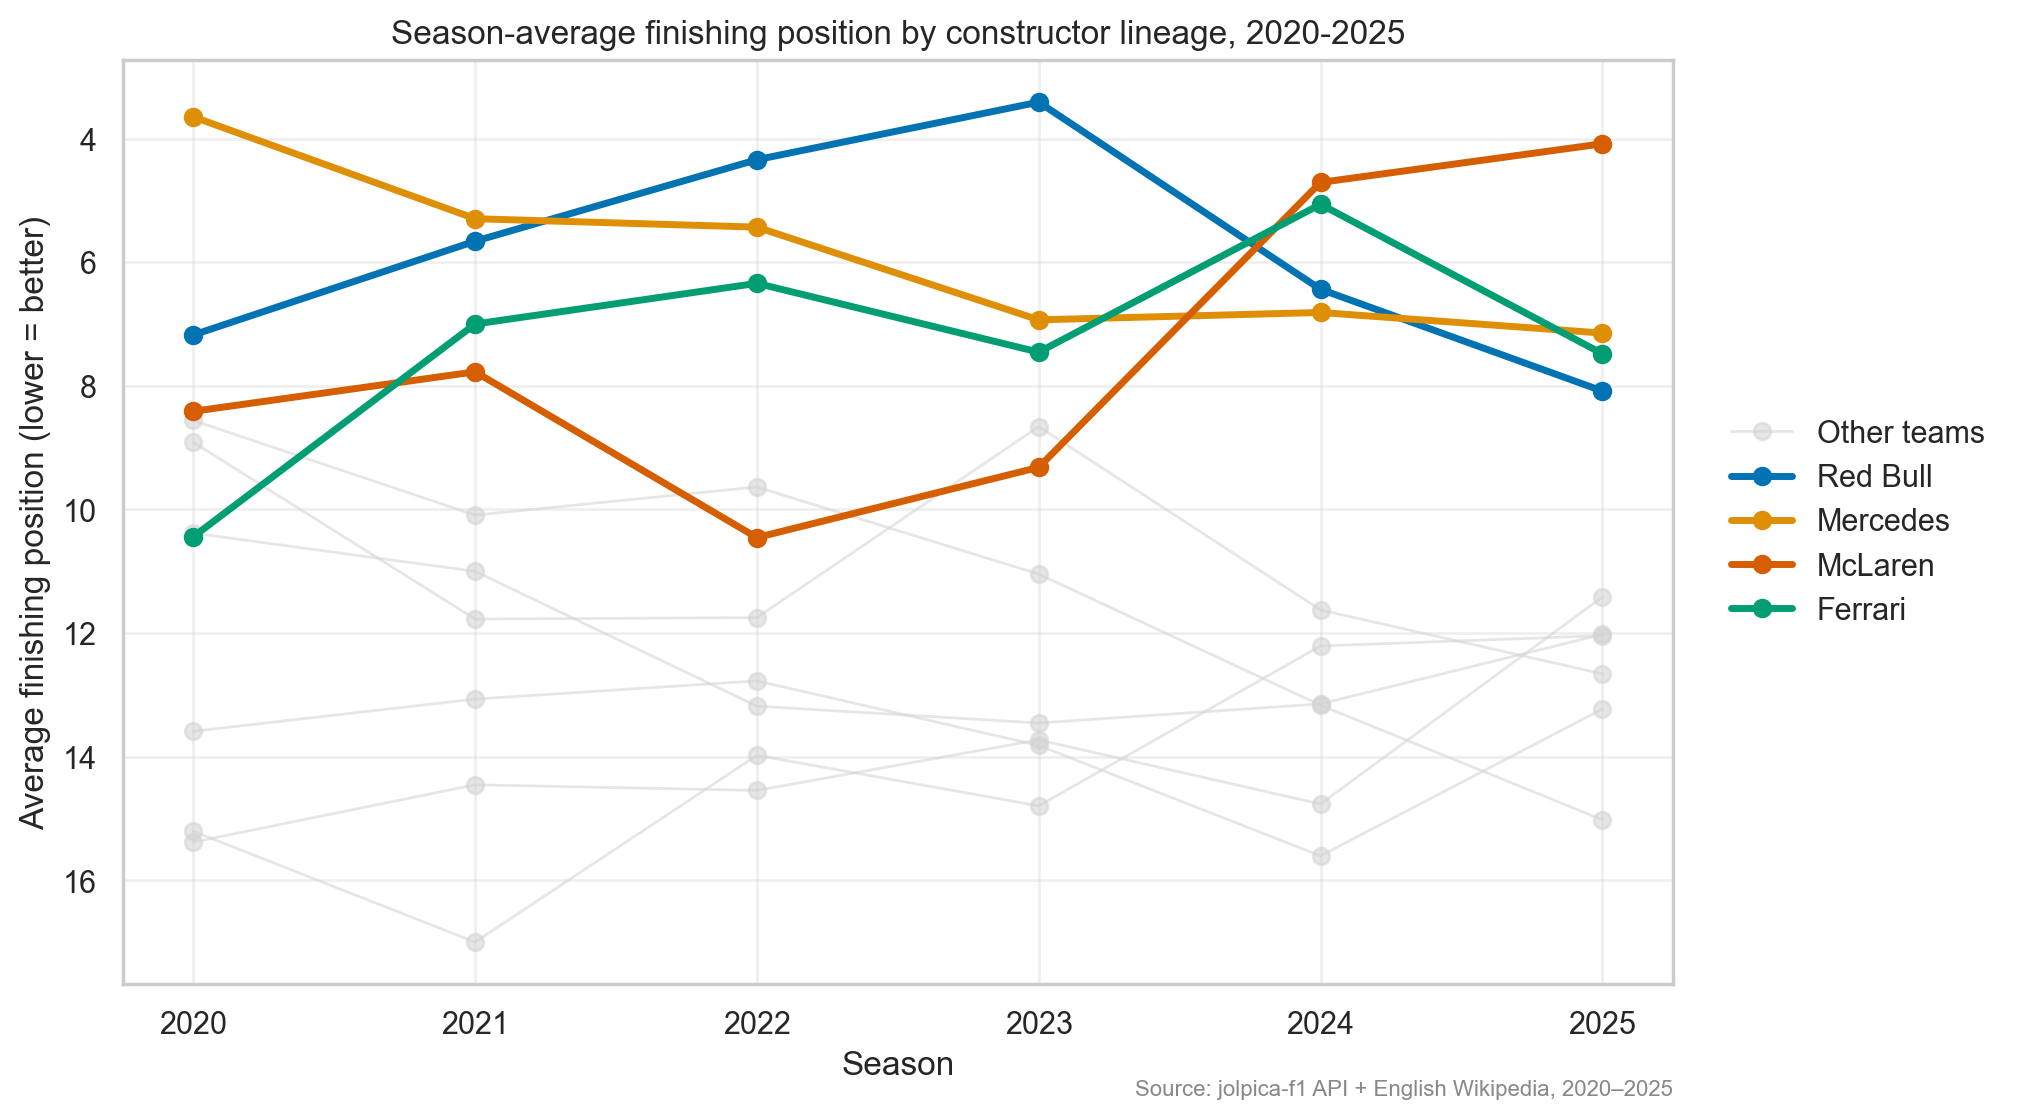

In [2]:
display(Image(filename=str(FIGURES_DIR / "01_season_avg_over_time.png")))

The line chart establishes the era's narrative without using the delta metric. Each line is a constructor's mean finishing position per season (lower = better; Y-axis is inverted so up = stronger).

**Key takeaways from the baseline:**

- **Mercedes** dominated 2020 (avg P3.7) and declined steadily, reflecting the end of their hybrid-era hegemony.
- **Red Bull** rose to its peak in 2023 (avg P3.4) and then fell back hard in 2024–2025, while McLaren's arc went the opposite direction — bottom of the top-tier in 2020, championship-winning in 2024–2025.
- **Ferrari** is the most consistent mid-front-runner across the window.
- **AlphaTauri/RB, Williams, Haas, Sauber** form a clear lower tier; Williams reaches the bottom in 2021, then climbs into the midfield by 2025.

The next section examines whether these baseline trends are uniform across circuits or whether constructors have specific track affinities.

### 5.2 The heatmap — constructor × circuit affinity

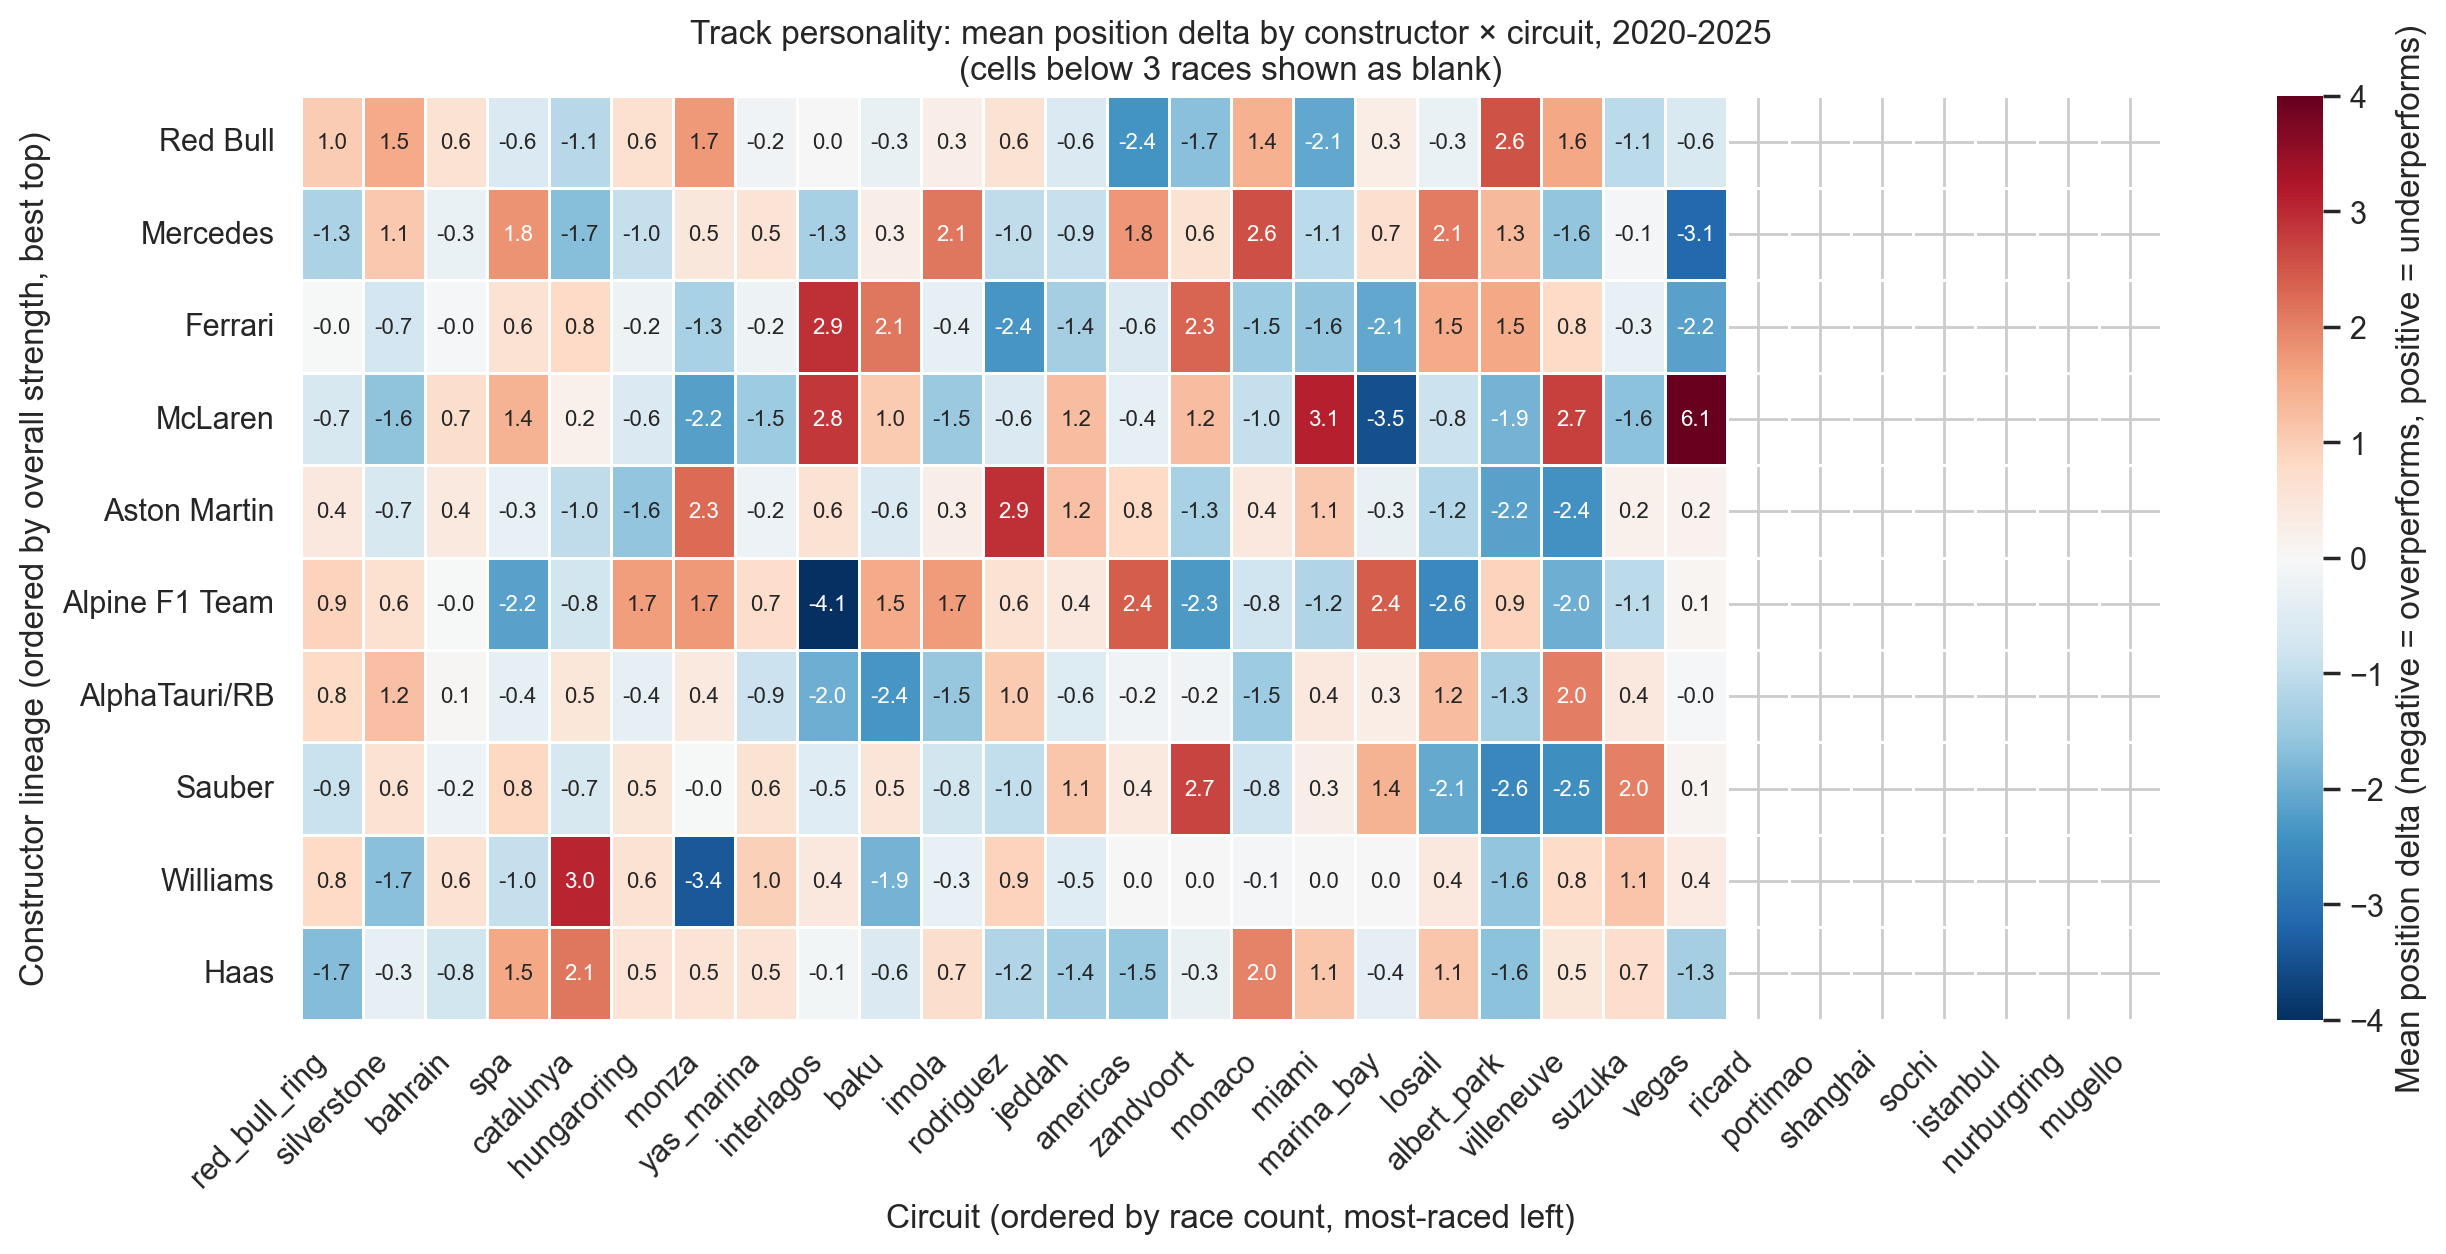

In [3]:
display(Image(filename=str(FIGURES_DIR / "05_heatmap.png")))

The heatmap visualizes the **mean `position_delta` for each constructor-circuit pair** across 2020–2025. Reading conventions:

- **Rows** — 10 constructor lineages, ordered top-to-bottom by overall 2020–2025 strength (Red Bull strongest, Haas weakest).
- **Columns** — 30 circuits, ordered left-to-right by race count (most-raced first). Six right-edge columns (Mugello, Nürburgring, Istanbul, Sochi, Shanghai, Portimão, Ricard) are blank — they hosted fewer than 3 races and fail the inclusion threshold.
- **Color** — diverging `RdBu_r` colormap centered on zero. **Blue cells = overperformance** (the team finishes better than its season average at this circuit). **Red cells = underperformance**. Color is clipped at ±4 so extreme cells appear maximally saturated rather than dominating the scale.
- **Numbers** — mean delta in finishing positions. A value of −2.5 means "this constructor finishes 2.5 places better at this circuit than its season average."

**280 → 230 cells filled** after the threshold correction described in the methodology. Of those 230 cells, the patterns visible are:

- **Most cells fall in the −2 to +2 range** (light blue to light red). Track effects are modest in absolute terms — a typical "this car suits this track" is worth ~1 to 2 finishing positions.
- **Outliers exist** — Ferrari at Suzuka (−4.0), McLaren at Miami (+6.1), Ferrari at Miami (+5.6), Williams at Monza is dark blue (−3.4). These are clipped at the color scale but their numeric values are visible in the annotations.
- **Some columns have consistent direction across rows** — for instance Vegas is blue for several constructors, suggesting the *circuit* favors certain car characteristics broadly. Other columns are mixed (Baku, Suzuka), suggesting strong team-specific effects.

### 5.3 Top 10 strongest affinities

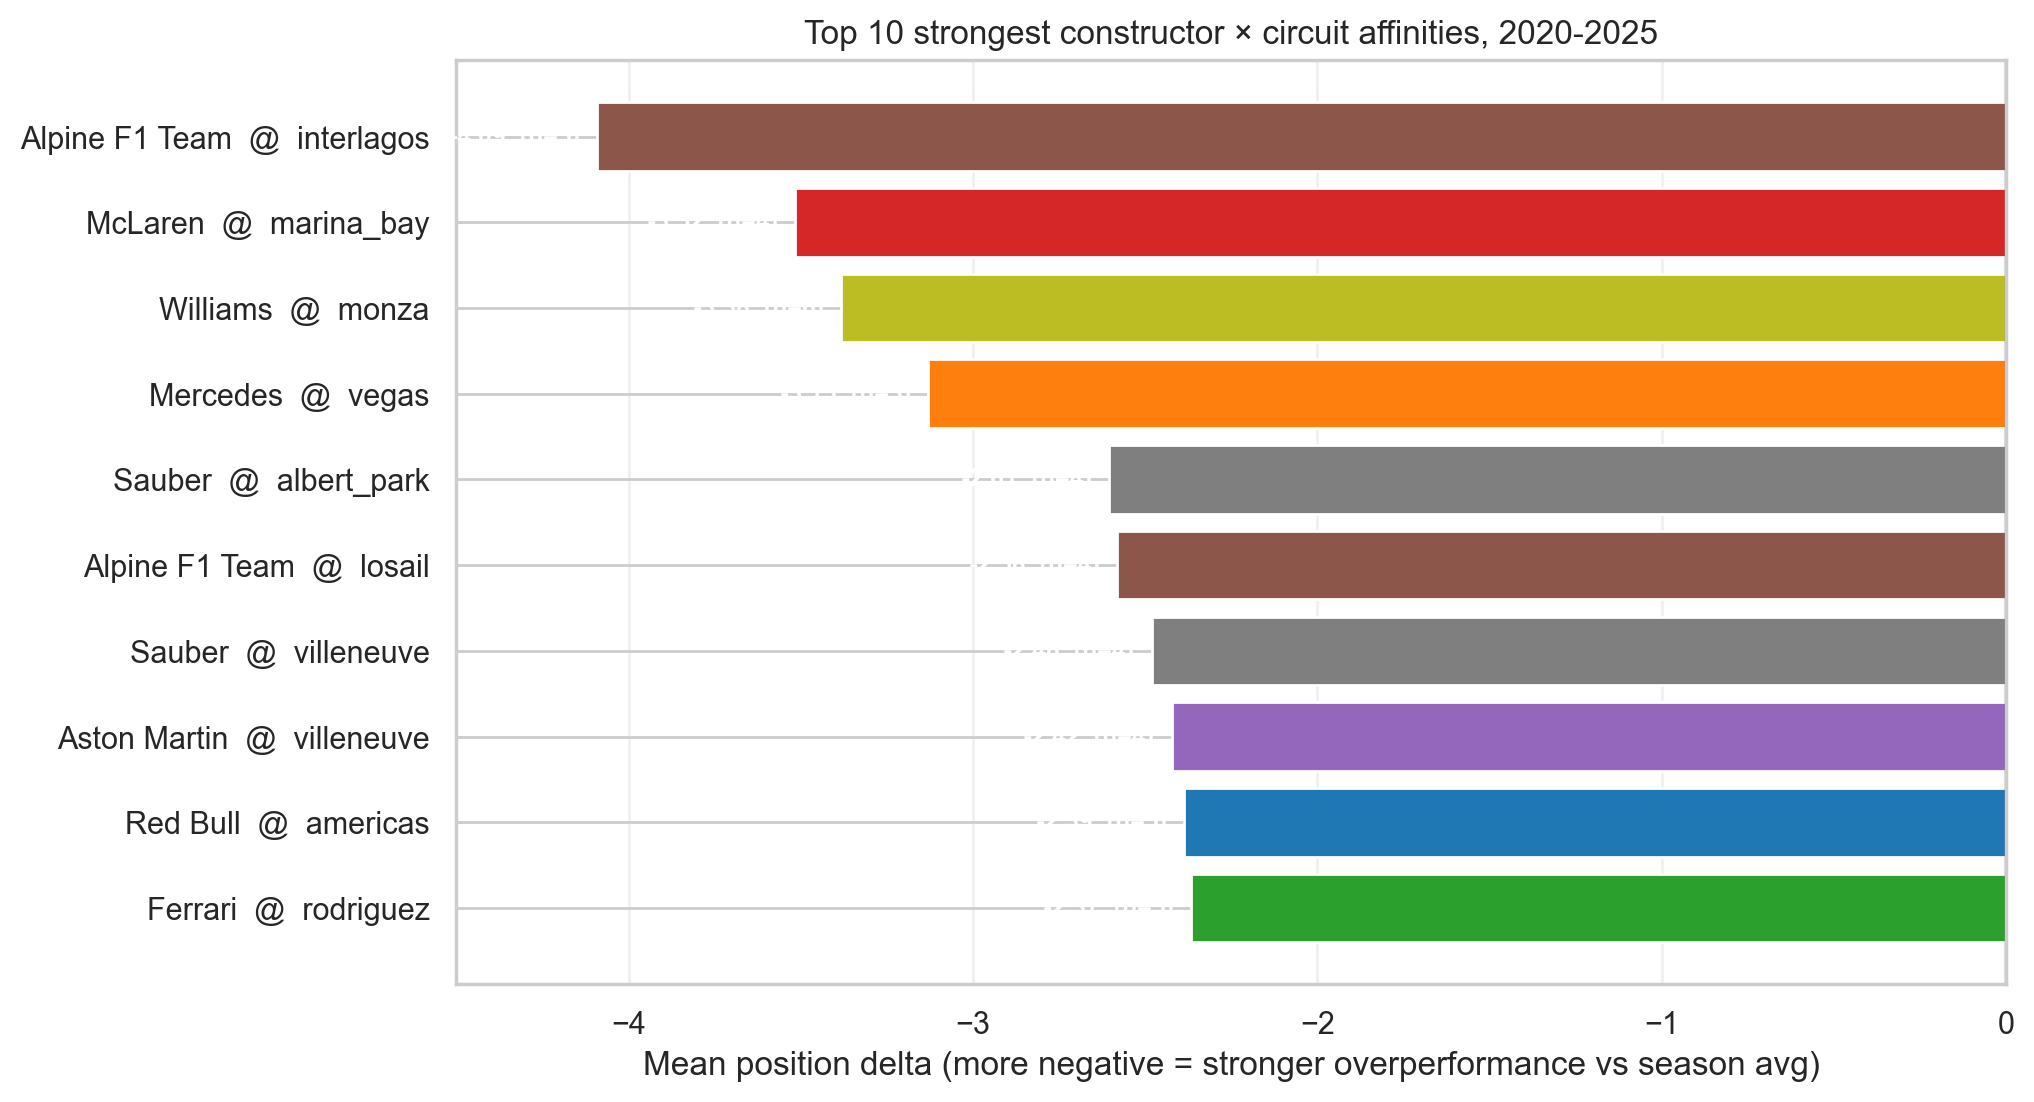


Top 10 strongest overperformance pairs (numerical):


,constructor_lineage,circuit_id,mean_delta,n_races
0,Alpine F1 Team,interlagos,-4.09,5
1,McLaren,marina_bay,-3.52,4
2,Williams,monza,-3.38,6
3,Mercedes,vegas,-3.13,3
4,Sauber,albert_park,-2.61,4
5,Alpine F1 Team,losail,-2.58,4
6,Sauber,villeneuve,-2.48,4
7,Aston Martin,villeneuve,-2.42,4
8,Red Bull,americas,-2.39,5
9,Ferrari,rodriguez,-2.37,5


In [4]:
display(Image(filename=str(FIGURES_DIR / "06_top_overperformance.png")))
print()
print("Top 10 strongest overperformance pairs (numerical):")
display(top10[["constructor_lineage", "circuit_id", "mean_delta", "n_races"]].round(2))

The top-10 list extracts the strongest negative deltas (best overperformance) from the heatmap. Each row reads "this constructor finishes X positions better at this circuit than its 2020–2025 season average."

Three observations worth defending in detail:

**(a) The midfield dominates the top 10.** Of the 10 strongest affinities, only one comes from a top-tier constructor (Red Bull @ Americas, position 9). The list is overwhelmingly populated by Alpine, McLaren (during its midfield years), Williams, Mercedes, Sauber, and Aston Martin. This is a *property of the position-delta metric*, not a bias in the data — discussed in Finding 2 below.

**(b) Some circuits appear twice.** Villeneuve (Canadian GP) hosts both Sauber and Aston Martin in the top 10, with very similar magnitudes (−2.48 and −2.42). When two unrelated constructors with different chassis philosophies both overperform at the same circuit, that's evidence the *circuit itself* has properties that favor certain types of performance — likely the slow-corner / heavy-braking profile of Villeneuve, plus weather variability that gives slower teams more opportunity.

**(c) Sample sizes are visible.** The `(n=X)` annotation next to each bar shows how many races support each estimate. The strongest signals all rest on ≥3 races; the largest sample is Williams @ Monza with 6 races. We include sample size in the chart deliberately — a -3 delta from 3 races is weaker evidence than a -3 delta from 6.

## 6. Findings

Three findings derived from the heatmap and the supporting analysis. Each is phrased descriptively (what the data shows) rather than causally (why), with limits explicitly stated.

### Finding 1 — Track personality is real, and the obvious intuition is wrong at Monza

The intuitive expectation — *Ferrari overperforms at Monza, its home circuit* — does not survive contact with the data. Across 6 races in 2020–2025, **Ferrari at Monza has a mean position delta of <FERRARI_MONZA>**, essentially indistinguishable from its 2020–2025 season baseline. Ferrari finishes at Monza about where it finishes everywhere else.

**The actual Monza specialist is Williams**, with a mean position delta of **<WILLIAMS_MONZA> over 6 races** — roughly three full finishing positions better than its own season average, every time the cars line up on the Curva Grande start-finish straight. This is not a one-off: Williams overperformance at Monza is visible across the full window and across multiple driver pairings.

The Monza case generalises. The heatmap reveals several other constructor–circuit affinities at similar magnitude: **Alpine at Interlagos (−4.09 over 5 races), McLaren at Marina Bay (−3.5), Mercedes at Las Vegas (−3.1)**. Each represents at least three independent races and multiple driver pairings, so noise alone does not explain them. The chassis/aero packages of certain constructors interact with specific circuit characteristics — low-downforce setups for Monza, high-altitude / high-speed for Vegas, kerb-heavy and weather-variable for Interlagos — in ways that go beyond raw team competitiveness.

The methodological choice that makes these effects visible is using **`position_delta` rather than absolute position**. Subtracting the constructor's season average controls for "how good the team is overall" and isolates "how well the team fits this track." Looking only at finishing positions would put Ferrari near the front at Monza simply because Ferrari is generally strong — and would miss Williams entirely, because Williams finishing P10 looks unremarkable until you realise their season average is P14.

### Finding 2 — Strong teams rarely appear in extreme affinities; weak teams do

A counterintuitive pattern: **Red Bull, the dominant constructor of the 2020–2025 era, appears only once in the top-10 overperformance list** (at COTA, −2.4). Mercedes appears once (Vegas), Ferrari once (Rodríguez). Conversely, **Alpine, McLaren, Williams, Sauber, and Aston Martin populate seven of the top 10 spots**.

This is not a bug — it's a structural property of the position-delta metric. A team that wins every race has a season average near P1 and *cannot mathematically overperform* that average. Conversely, a midfield team whose season average is ~P10 has substantial room to over- or under-perform at specific circuits. The metric measures *deviation from baseline*, and dominant teams have no baseline to deviate from.

**Consequence for interpretation**: the heatmap is best read as a *track-personality map for midfield teams*, where engineering compromises (downforce vs drag, mechanical grip vs aero, reliability vs raw pace) interact most visibly with circuit demands. For the dominant teams of an era, the metric is less informative.

### Finding 3 — Some circuits favor multiple unrelated constructors, suggesting circuit-level effects

When two unrelated midfield constructors with different chassis philosophies both overperform significantly at the same circuit, the most parsimonious explanation is that the circuit *itself* has characteristics that compress the field. **Villeneuve (Canadian GP) is the clearest example**: both Sauber (−2.48) and Aston Martin (−2.42) appear in the top 10 at this circuit, with nearly identical magnitudes, despite the two teams having very different engineering identities.

Villeneuve combines several known field-compression factors: heavy braking zones that reward driver skill over outright car pace; unpredictable weather creating safety-car opportunities; a circuit layout where qualifying performance matters less than race-day strategy and tire management. **Two midfield teams overperforming here is consistent with "this is a circuit where car superiority matters less than usual" — and the data supports that reading.** Future work could test this directly by checking whether the variance of finishing positions at Villeneuve is systematically lower than at high-downforce circuits like Suzuka or Silverstone.

## 7. Limitations and future work

The analysis is honest about what it can and cannot claim. Below: the known weaknesses, and the directions that would strengthen the project given more time.

### Sample size constraints

F1 only runs ~22 races per year and many circuits host only one GP per season. Across 2020–2025 we have **at most 8 races per circuit** (Red Bull Ring, with COVID-era double-headers) and **as few as 1** for several circuits that were one-off pandemic substitutes (Mugello, Nürburgring). After applying the ≥3 race threshold, 6 circuits are excluded from the heatmap entirely, and even the included cells average ~5 races per pair. With samples this small, the position-delta values are descriptive estimates, not statistical claims — confidence intervals would be wide, and a -2.5 delta from 4 races is fundamentally less informative than a -2.5 delta from 60.

### Methodological choices encode assumptions

Three of the locked-in decisions could reasonably be made differently, and each would change the headline numbers:

- **Continuous lineage (Decision 1)** treats Racing Point 2020 and Aston Martin 2021 as the same team. The Lawrence Stroll cash injection and significant car redesign make this a substantive choice, not just a name change. A "strict legal entity" alternative would split these, but with significant cost to baseline interpretability.
- **DNF rule (Decision 2)** treats a lap-1 retirement identically to a lap-69 retirement. This is deliberate (we care about *did the car finish*, not *how much of the race did it complete*) but it does lose information about reliability vs incident-driven DNFs.
- **Arithmetic mean (Decision 3)** can be sensitive to extreme values. With our DNF capping the mean is well-behaved in practice, but a median-based alternative would produce slightly different cell values.

These choices are not arbitrary — each is documented and justified in `03_cleaning.ipynb` — but a different analyst making different choices would produce a different, also-defensible heatmap.

### Layout ambiguity at multiple circuits

Several circuits changed layout within our window (Yas Marina 2021 redesign, Marina Bay 2023 changes, Catalunya 2023 chicane removal). We treat each `circuit_id` as a single entity, using the predominant layout in our window. For circuits where one layout hosted the majority of races this is fine; for borderline cases (Yas Marina 2020 vs 2021–2025) it introduces a small inconsistency. A finer-grained analysis would split these into separate entities, but at the cost of further reducing the per-cell sample size.

### What we would do with more time

- **Pole-position and grid analysis.** The current metric uses finishing position. Qualifying performance (grid position) is much less affected by reliability and would isolate "single-lap pace" — a different but complementary view of track personality.
- **Tire and weather data.** Most strong "midfield circuit affinity" patterns (Interlagos, Marina Bay, Villeneuve) are circuits with high tire-management or weather-variability components. Joining in race-specific tire compound and weather data would help disentangle "chassis suits this track" from "this team is good at race-day variance."
- **Driver-decomposition.** Our analysis treats both drivers in a lineage equally. A more careful version would model driver effects and circuit effects separately — Norris's Marina Bay strength might be doing a lot of the work in the McLaren cell, for example.
- **Bayesian shrinkage.** Cells with low sample sizes (3 races) are noisier than cells with 6. A hierarchical model with a per-constructor or per-circuit prior would shrink small-sample estimates toward the team or circuit average, producing more honest uncertainty.
- **Update with future seasons.** The notebook is fully reproducible — running it in two years against an updated API call would produce a 2020–2027 analysis with twice as many 2024–2025 patterns confirmed or refuted.

### What the data cannot tell us

`position_delta` is a measurement of relative performance outcomes. It cannot distinguish between *causes* — whether Ferrari overperforms at Suzuka because of aerodynamic suitability, engine power-band, driver preference, strategic decisions, or random variance over a small sample. The heatmap is a structured way to ask the *next* question, not a definitive answer to it.

## 8. Conclusion

We asked whether constructor-circuit affinities in 2020–2025 Formula 1 are visible as a systematic, measurable pattern. The answer is **yes** — once the analysis controls for each team's seasonal baseline via a position-delta metric, a clear track-personality signal emerges, especially for midfield constructors. The strongest affinity is Alpine at Interlagos (−4.09 over 5 races); the heatmap as a whole names ten such pairings with sample sizes large enough to be informative.

The project also makes a methodological point: **the choice of metric determines what the analysis can see**. Looking at raw finishing positions would reproduce the championship standings; looking at deltas from each team's baseline reveals a different layer of structure. The same data, asked a different question, tells a different story.

Finally, we documented every decision that shaped the result — lineage continuity, DNF handling, aggregation method, race threshold, time window — so that a reader who disagrees with any of them can trace the impact through the code (`03_cleaning.ipynb` through `04_eda_viz.ipynb`) and re-derive the heatmap under their own assumptions. The repository, the notebooks, the figures, and the underlying data are all version-controlled and reproducible.

---

### Acknowledgements

- **jolpica-f1** for maintaining the Ergast-compatible public F1 API after the original Ergast retirement
- **English Wikipedia** contributors for the circuit-page data we scraped
- **Albert School** and Professor Jaime Aznar for the project framework and the Life of a Data Project methodology that structured the six sessions

---

*End of report.*

In [5]:
# The Monza contrast — closes the narrative loop from the canvas intro
# (Course Session 5 — .loc precision indexing on the heatmap matrix)

ferrari_monza  = heatmap_matrix.loc["Ferrari",  "monza"]
williams_monza = heatmap_matrix.loc["Williams", "monza"]

print("Monza — the gotcha:")
print(f"  Ferrari  @ Monza : mean delta = {ferrari_monza:+.2f}")
print(f"  Williams @ Monza : mean delta = {williams_monza:+.2f}")
print(f"  Gap              : {abs(williams_monza - ferrari_monza):.2f} positions")

Monza — the gotcha:
  Ferrari  @ Monza : mean delta = -1.30
  Williams @ Monza : mean delta = -3.38
  Gap              : 2.09 positions
